In [2]:
import numpy as np
from typing import Optional, Dict, Callable, Any
import torch
from torch import nn
from torch.utils.data import DataLoader
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Change Working Dir To the Project Working Dir (for Noam)

In [8]:
import ipynbname
# change the dir to the grandparent directory of the current working directory

note_dir = ipynbname.path().parent
grandparent_dir = note_dir.parent.parent
os.chdir(grandparent_dir)
print(os.getcwd())  # Check the cwd has updated

c:\Users\noams\Python Projects\Audio_processing_project


In [9]:
df_w_h_n = pd.read_csv(r"C:\Users\noams\Downloads\CremaD - Cos Sil - w. happy neutral.csv")
df_wo_h_n = pd.read_csv(r"C:\Users\noams\Downloads\CremaD - Cos Sil - w.o. happy neutral.csv")
display(df_w_h_n)
display(df_wo_h_n)

,num clusters,Cosine Silhouette
0,2,0.500
1,3,0.399
2,4,0.397
3,5,0.298
4,6,0.303
5,7,0.275
6,8,0.288
7,9,0.226
8,10,0.201


,num clusters,Cosine Silhouette
0,2,0.527
1,3,0.432
2,4,0.439
3,5,0.339
4,6,0.325
5,7,0.271
6,8,0.273
7,9,0.253
8,10,0.254


In [10]:
w_h_n = df_w_h_n["Cosine Silhouette"].to_numpy()
wo_h_n = df_wo_h_n["Cosine Silhouette"].to_numpy()

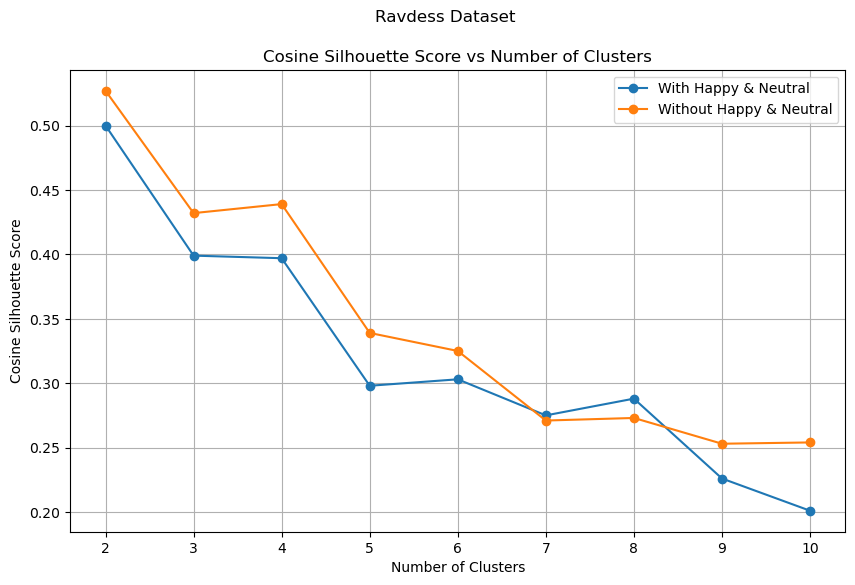

In [11]:
# plot the two series in one plot
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), w_h_n, marker='o', label='With Happy & Neutral')
plt.plot(range(2, 11), wo_h_n, marker='o', label='Without Happy & Neutral')
plt.xticks(range(2, 11))
plt.xlabel('Number of Clusters')
plt.ylabel('Cosine Silhouette Score')
plt.title('Cosine Silhouette Score vs Number of Clusters')
# add title
plt.suptitle('Ravdess Dataset')
plt.legend()
plt.grid()
plt.show()

In [48]:
# generate a 2d numpy array that contains N clusters, each with about K samples, where N is the number of clusters and K is the number of samples per cluster
# their should be a center point for each cluster, and the samples should be normally distributed around the center point
# K is the mean number of samples per cluster, and the standard deviation is S
import numpy as np

def generate_clusters_2d(N, K, S, cluster_spread=0.5, random_state=None):
    """
    Generate a 2D dataset consisting of N clusters, each with about K samples.
    Each cluster has its own random center and samples are normally distributed around it.

    Parameters
    ----------
    N : int
        Number of clusters.
    K : int
        Mean number of samples per cluster.
    S : float
        Standard deviation of number of samples per cluster.
    cluster_spread : float, optional
        Controls how far apart the cluster centers are.
    random_state : int, optional
        Random seed for reproducibility.

    Returns
    -------
    X : np.ndarray, shape (sum(K_i), 2)
        2D samples for all clusters.
    y : np.ndarray, shape (sum(K_i),)
        Cluster labels (0, 1, ..., N-1).
    centers : np.ndarray, shape (N, 2)
        The coordinates of each cluster center.
    """
    rng = np.random.default_rng(random_state)
    
    # generate random cluster centers
    # centers = rng.uniform(-N * cluster_spread, N * cluster_spread, size=(N, 2))
    centers = np.array([[1,1], [1,100], [100,1], [100,100]])
    
    X, y = [], []
    for i in range(N):
        # random number of samples for this cluster
        n_samples = max(1, int(rng.normal(K, S)))
        # samples around the cluster center
        samples = rng.normal(loc=centers[i], scale=cluster_spread, size=(n_samples, 2))
        
        X.append(samples)
        y.append(np.full(n_samples, i))
    
    return np.vstack(X), np.concatenate(y), centers


In [61]:
# Get the cluster data
X, y, centers = generate_clusters_2d(N=4, K=50, S=10, cluster_spread=5, random_state=200)

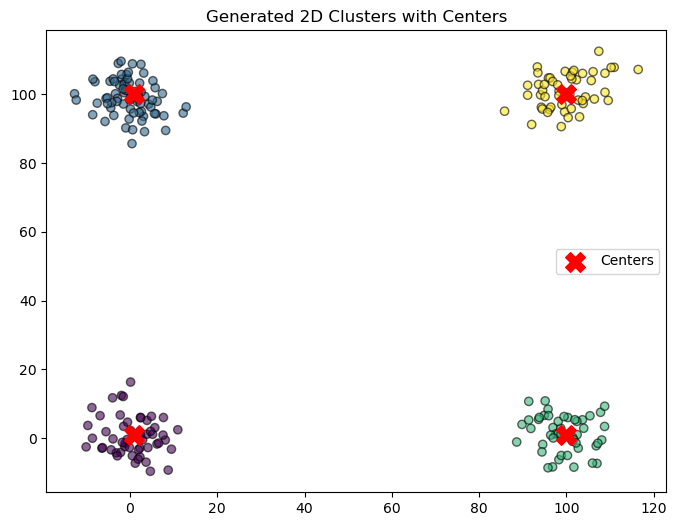

In [62]:
# plot the clusters and their centers
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis'
, alpha=0.6, edgecolor='k')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s
=200, marker='X', label='Centers')
plt.title('Generated 2D Clusters with Centers')
plt.legend()
plt.show()

In [63]:

# evaluate clustering function
cluster_dict = {num:evaluate_clustering(X, y, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

{2: {'Euclidean clustering ARI': 0.5030347072693965,
  'Cosine clustering ARI': 0.3447295118818251,
  'Euclidean Silhouette': 0.5516977863579824,
  'Cosine Silhouette': 0.6745893249601714,
  'Euclidean': {'intra_mean': 53.91265912888943,
   'inter_mean': 119.93051754019523,
   'separation': 2.2245335228870156},
  'Cosine': {'intra_mean': 0.34062996790109124,
   'inter_mean': 0.9961734718026223,
   'separation': 2.9245033193670187}},
 3: {'Euclidean clustering ARI': 0.7763774041756133,
  'Cosine clustering ARI': 0.494499543408004,
  'Euclidean Silhouette': 0.7062424532811745,
  'Cosine Silhouette': 0.7769632480330829,
  'Euclidean': {'intra_mean': 24.4381227910765,
   'inter_mean': 112.97264730121542,
   'separation': 4.622803816276225},
  'Cosine': {'intra_mean': 0.2218895054705505,
   'inter_mean': 1.2792681393043797,
   'separation': 5.765338638217687}},
 4: {'Euclidean clustering ARI': 1.0,
  'Cosine clustering ARI': 0.7194800539018629,
  'Euclidean Silhouette': 0.9037140152781501,


In [64]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"
df.reset_index(inplace=True)


display(df)

,num clusters,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra_mean,Euclidean inter_mean,Euclidean separation,Cosine intra_mean,Cosine inter_mean,Cosine separation
0,2,0.503035,0.344730,0.551698,0.674589,53.912659,119.930518,2.224534,0.340630,0.996173,2.924503
1,3,0.776377,0.494500,0.706242,0.776963,24.438123,112.972647,4.622804,0.221890,1.279268,5.765339
2,4,1.000000,0.719480,0.903714,0.865896,9.339310,113.142841,12.114689,0.127817,1.080870,8.456383
3,5,0.936545,0.727381,0.786406,0.897413,8.461233,104.081216,12.300952,0.080980,1.179325,14.563099
4,6,0.782393,0.725457,0.604623,0.906296,7.811605,99.054512,12.680431,0.048095,1.169773,24.322267
5,7,0.709349,0.735137,0.487440,0.921310,7.420212,98.721819,13.304447,0.037845,1.160652,30.668920
6,8,0.617358,0.739704,0.467270,0.914056,7.034352,94.346131,13.412200,0.032998,1.125156,34.097351
7,9,0.536725,0.720847,0.349826,0.834999,6.833202,96.706219,14.152401,0.028453,1.120124,39.367505
8,10,0.503016,0.712081,0.338324,0.824665,6.576493,95.639719,14.542663,0.022686,1.104129,48.670373


In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, pairwise_distances
from sklearn.preprocessing import normalize

In [8]:
def intra_inter_scores(X, y, metric="euclidean"):
    """Compute intra- and inter-cluster distance statistics for labels y using the given metric.

    Returns:
      - intra_mean: mean of within-class pairwise distances
      - inter_mean: mean of between-class pairwise distances
      - separation: inter_mean / intra_mean
    """
    # 1) Compute pairwise distance matrix for the chosen metric
    dist_matrix = pairwise_distances(X, metric=metric)
    # 2) Unique label identifiers present in y
    labels = np.unique(y)

    # 3) Accumulators for intra- and inter-class distances
    intra_dists = []
    inter_dists = []

    # 4) Intra-class distances: average of upper triangle (exclude diagonal)
    for label in labels:
        idx = np.where(y == label)[0]
        if len(idx) > 1:
            d = dist_matrix[np.ix_(idx, idx)]
            intra_dists.append(d[np.triu_indices_from(d, k=1)].mean())

    # 5) Inter-class distances: mean distances across class pairs
    for i, lbl1 in enumerate(labels):
        for lbl2 in labels[i+1:]:
            idx1 = np.where(y == lbl1)[0]
            idx2 = np.where(y == lbl2)[0]
            d = dist_matrix[np.ix_(idx1, idx2)]
            inter_dists.append(d.mean())

    # 6) Aggregate metrics
    return {
        "intra_mean": np.mean(intra_dists),
        "inter_mean": np.mean(inter_dists),
        "separation": np.mean(inter_dists) / np.mean(intra_dists)
    }

In [9]:
from sklearn.preprocessing import normalize


def evaluate_clustering(X, y, n_clusters, random_state=42, print_results=True, return_results=False):
    # KMeans clustering with Euclidean distance
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters_euc = kmeans.fit_predict(X)
    
    # KMeans clustering with Cosine distance
    X_cosine = normalize(X, norm='l2', axis=1)        # put points on the unit sphere
    clusters_cos = kmeans.fit_predict(X_cosine)
    
    if print_results:
        # ---- STEP 4: Evaluation (since you have ground truth labels) ----
        print("Euclidean clustering ARI:", adjusted_rand_score(y, clusters_euc))
        print("Cosine clustering ARI:", adjusted_rand_score(y, clusters_cos))
        print("Euclidean Silhouette:", silhouette_score(X, clusters_euc, metric="euclidean"))
        print("Cosine Silhouette:", silhouette_score(X_cosine, clusters_cos, metric="cosine"))
        
        # Intra-cluster and inter-cluster scores
        print("Euclidean:", intra_inter_scores(X, clusters_euc, metric="euclidean"))
        print("Cosine:", intra_inter_scores(X, clusters_cos, metric="cosine"))
    
    if return_results:
        return {
                    "Euclidean clustering ARI": adjusted_rand_score(y, clusters_euc),
                    "Cosine clustering ARI": adjusted_rand_score(y, clusters_cos),
                    "Euclidean Silhouette": silhouette_score(X, clusters_euc, metric="euclidean"),
                    "Cosine Silhouette": silhouette_score(X_cosine, clusters_cos, metric="cosine"),
                    "Euclidean": intra_inter_scores(X, clusters_euc, metric="euclidean"),
                    "Cosine": intra_inter_scores(X, clusters_cos, metric="cosine")
                }